#Business Understanding
**BO  :** Réduire les délais de diagnostic des maladies du foie en automatisant l'analyse des résultats d'analyses sanguines des patients.

**DSO :** Construire un modèle de classification binaire capable de prédire si un patient est atteint d'une maladie du foie (classe 1) ou non (classe 2) avec une accuracy maximale.

#Data Understanding

In [2]:
import pandas as pd
import os

# Load data from local CSV file
df = pd.read_csv("indian_liver_patient.csv")
print(df.shape)
print(df.isnull().sum())
print(df['Dataset'].value_counts())

(583, 11)
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64
Dataset
1    416
2    167
Name: count, dtype: int64


In [3]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("indian_liver_patient.csv")

# 2.1 Infos générales
print("=== SHAPE ===")
print(df.shape)

print("\n=== TYPES ===")
print(df.dtypes)

print("\n=== STATISTIQUES ===")
print(df.describe())

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== CIBLE ===")
print(df['Dataset'].value_counts())

=== SHAPE ===
(583, 11)

=== TYPES ===
Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Dataset                         int64
dtype: object

=== STATISTIQUES ===
              Age  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
count  583.000000       583.000000        583.000000            583.000000   
mean    44.746141         3.298799          1.486106            290.576329   
std     16.189833         6.209522          2.808498            242.937989   
min      4.000000         0.400000          0.100000             63.000000   
25%     33.000000         0.800000          0.200000            175.500000   
50%     45.000000         1.000000     

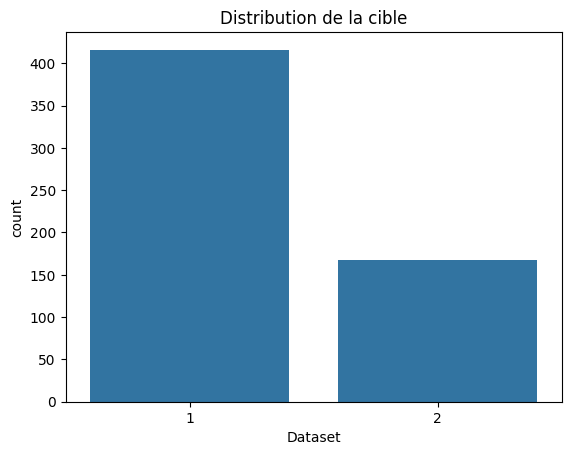

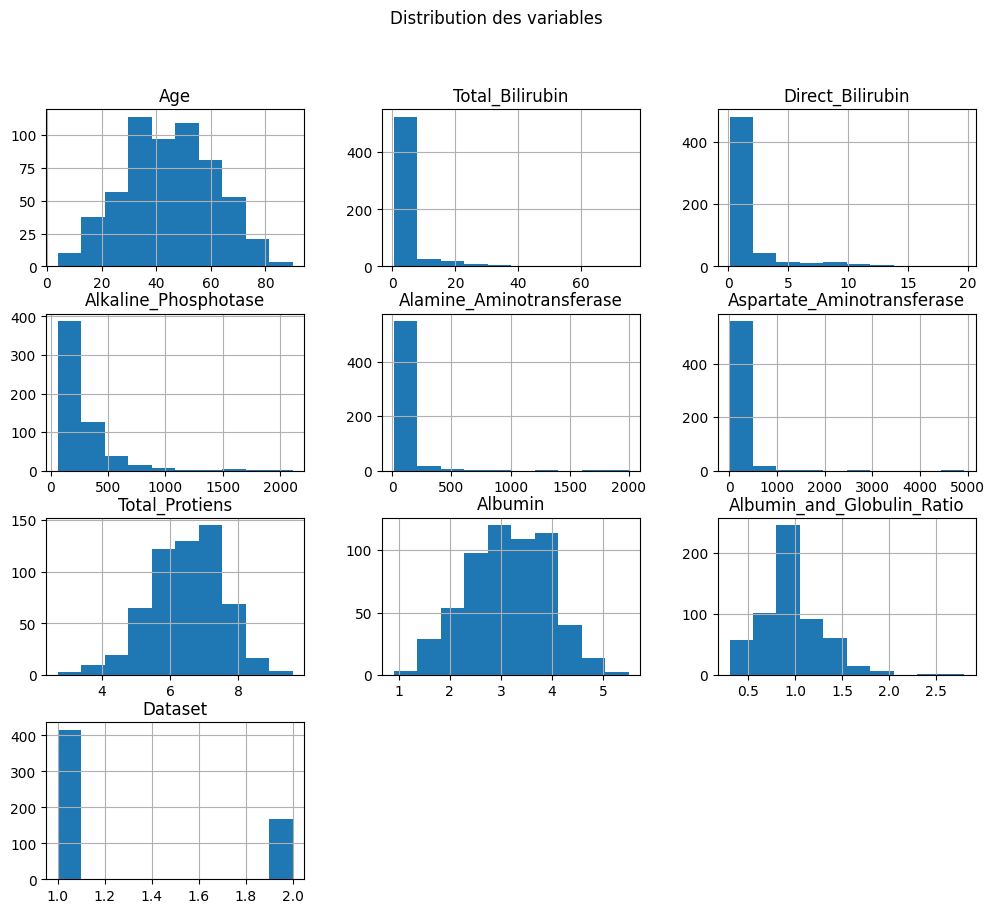

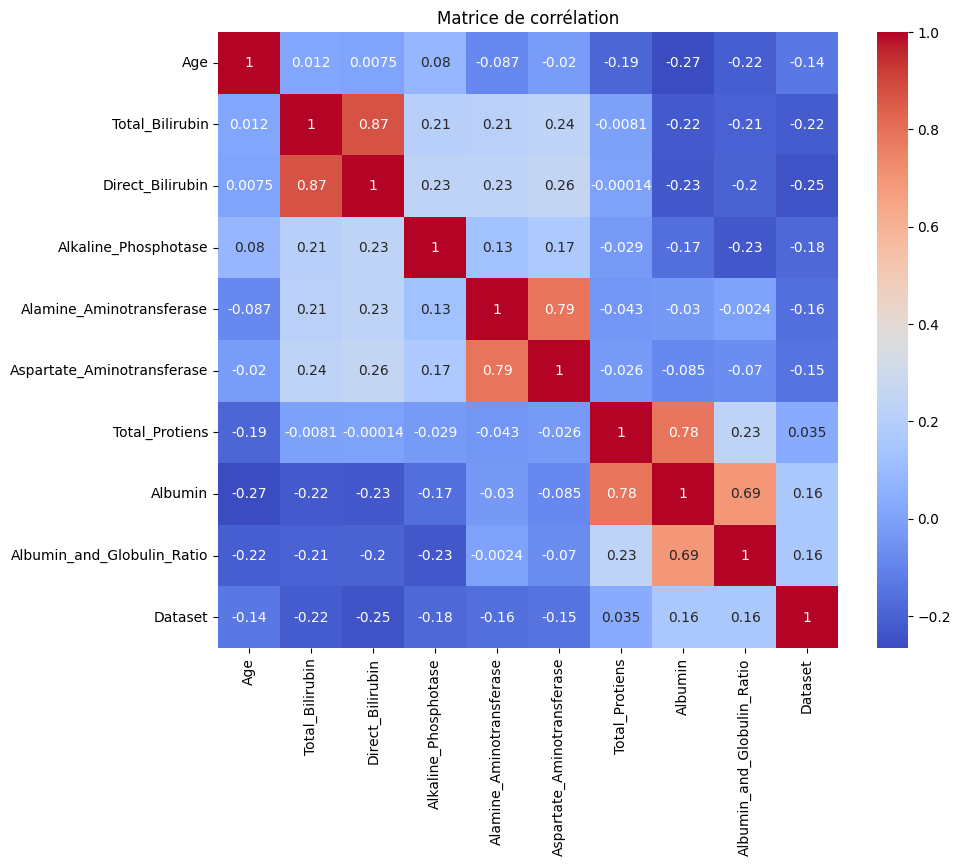

In [5]:
# 2.2 Visualisations
# Distribution de la cible
sns.countplot(x='Dataset', data=df)
plt.title("Distribution de la cible")
plt.show()

# Distribution des variables numériques
df.hist(figsize=(12, 10))
plt.suptitle("Distribution des variables")
plt.show()

# Heatmap corrélations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

#Data Preparation

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2 = df.copy()

# 3.1 Gérer les valeurs manquantes
df2['Albumin_and_Globulin_Ratio'] = df2['Albumin_and_Globulin_Ratio'].fillna(
    df2['Albumin_and_Globulin_Ratio'].median())

# Drop remaining NaN values if any
df2 = df2.dropna()

print("NaN restants:", df2.isnull().sum().sum())

# 3.2 Encoder Gender (Male=1, Female=0)
le = LabelEncoder()
df2['Gender'] = le.fit_transform(df2['Gender'])

# 3.3 Séparer features et cible
X = df2.drop('Dataset', axis=1)
y = df2['Dataset']

# 3.4 Normaliser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nDonnées prêtes !")
print(X_scaled.head())

NaN restants: 0

Données prêtes !
        Age    Gender  Total_Bilirubin  Direct_Bilirubin  \
0  1.252098 -1.762281        -0.418878         -0.493964   
1  1.066637  0.567446         1.225171          1.430423   
2  1.066637  0.567446         0.644919          0.931508   
3  0.819356  0.567446        -0.370523         -0.387054   
4  1.684839  0.567446         0.096902          0.183135   

   Alkaline_Phosphotase  Alamine_Aminotransferase  Aspartate_Aminotransferase  \
0             -0.426715                 -0.354665                   -0.318393   
1              1.682629                 -0.091599                   -0.034333   
2              0.821588                 -0.113522                   -0.145186   
3             -0.447314                 -0.365626                   -0.311465   
4             -0.393756                 -0.294379                   -0.176363   

   Total_Protiens   Albumin  Albumin_and_Globulin_Ratio  
0        0.292120  0.198969                   -0.147529  
1 

#Modeling

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("="*60)
print("TRAINING BEST MODEL: LOGISTIC REGRESSION")
print("="*60)

# Train Logistic Regression (Best Model - 76% accuracy)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

print("\n✓ Logistic Regression model trained!")
print(f"Training accuracy: {lr.score(X_train, y_train):.2f}")

TRAINING BEST MODEL: LOGISTIC REGRESSION

✓ Logistic Regression model trained!
Training accuracy: 0.72



LOGISTIC REGRESSION - TEST SET EVALUATION

✓ Test Accuracy: 0.76

Classification Report:
                   precision    recall  f1-score   support

Liver Disease (1)       0.79      0.92      0.85        87
      Healthy (2)       0.56      0.30      0.39        30

         accuracy                           0.76       117
        macro avg       0.68      0.61      0.62       117
     weighted avg       0.73      0.76      0.73       117



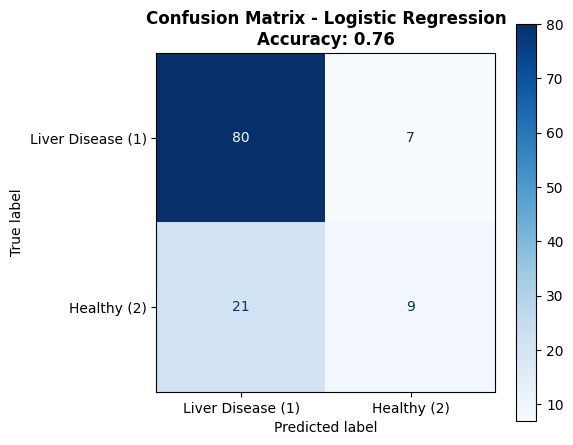

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("LOGISTIC REGRESSION - TEST SET EVALUATION")
print("="*60)

# Predictions
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)

print(f"\n✓ Test Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=["Liver Disease (1)", "Healthy (2)"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Liver Disease (1)", "Healthy (2)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Confusion Matrix - Logistic Regression\nAccuracy: {acc:.2f}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
!pip install xgboost -q


In [11]:
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np


In [17]:
from sklearn.model_selection import train_test_split

# Split to ensure y_train and y_test are defined
# Assuming X_scaled and y are available from previous executed cells.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [18]:
from sklearn.model_selection import train_test_split

# Split to ensure y_train and y_test are defined
# Assuming X_scaled and y are available from previous executed cells.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [19]:
# Entraîner XGBoost
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_clf.fit(X_train, y_train_xgb)

/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [20]:
# Prédictions et Accuracy XGBoost
y_pred_xgb = xgb_clf.predict(X_test)
acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f"=== XGBoost ===")
print(f"Accuracy : {acc_xgb:.2f}")
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=["Malade (1)", "Sain (2)"], zero_division=0))

=== XGBoost ===
Accuracy : 0.73
              precision    recall  f1-score   support

  Malade (1)       0.79      0.86      0.82        87
    Sain (2)       0.45      0.33      0.38        30

    accuracy                           0.73       117
   macro avg       0.62      0.60      0.60       117
weighted avg       0.70      0.73      0.71       117



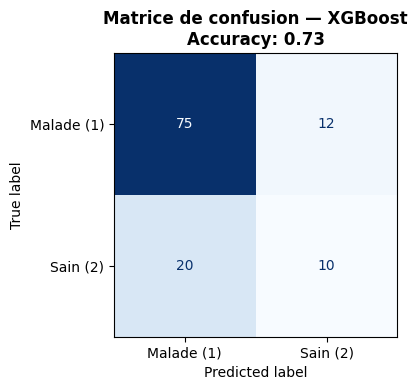

In [21]:
# Matrice de confusion XGBoost
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                               display_labels=["Malade (1)", "Sain (2)"])
fig_xgb, ax_xgb = plt.subplots(figsize=(5, 4))
disp_xgb.plot(ax=ax_xgb, colorbar=False, cmap='Blues')
ax_xgb.set_title(f"Matrice de confusion — XGBoost\nAccuracy: {acc_xgb:.2f}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Cross Validation XGBoost
# Ensure y is transformed for cross_val_score if necessary (y-1 for 0-1 labels)
scores = cross_val_score(xgb_clf, X_scaled, y - 1, cv=5, scoring='accuracy')
print(f"\nCross Validation (5-fold) :")
print(f"Scores : {scores.round(2)}")
print(f"Moyenne : {scores.mean():.2f} ± {scores.std():.2f}")

/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Cross Validation (5-fold) :
Scores : [0.68 0.74 0.65 0.59 0.72]
Moyenne : 0.68 ± 0.06


/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vanitas/Desktop/ML_2/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 800x600 with 0 Axes>

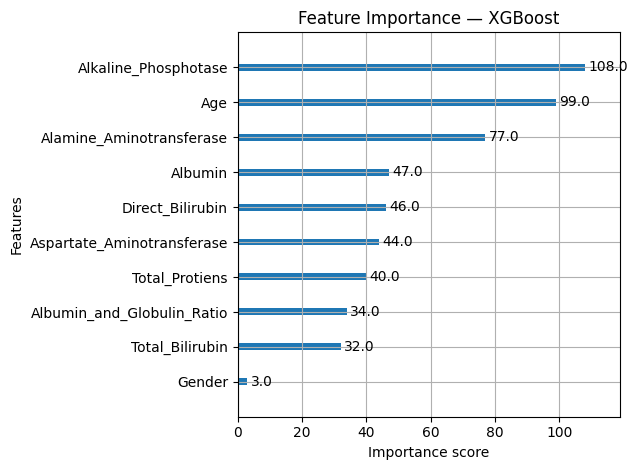

In [23]:
# Feature Importance XGBoost
plt.figure(figsize=(8, 6))
plot_importance(xgb_clf)
plt.title("Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

In [24]:
# Cellule 1 — Installer XGBoost et imbalanced-learn
!pip install xgboost imbalanced-learn -q

In [25]:
# Cellule 2 — Importer les bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split # Assurer que train_test_split est importé ici aussi

In [26]:
# Cellule 3 — Corriger le déséquilibre avec SMOTE

print("=== AVANT SMOTE ===")
print(Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("=== APRÈS SMOTE ===")
print(Counter(y_resampled))

=== AVANT SMOTE ===
Counter({1: 416, 2: 167})
=== APRÈS SMOTE ===
Counter({1: 416, 2: 416})


In [27]:
# Cellule 4 — Nouveau split équilibré
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled)

In [28]:
# Cellule 5 — XGBoost avec scale_pos_weight (gestion du déséquilibre)
# Rappel: y contient 1 et 2, mais XGBoost attend 0 et 1. La conversion se fait dans fit.
# Ici, nous convertissons les étiquettes pour XGBoost (1->0, 2->1) pour le calcul du ratio.
# Par convention, la classe minoritaire est souvent la classe positive.
# Dans le dataset original, la classe 2 est la minorité. Nous la mappons à 1 pour XGBoost.
# Donc, le ratio est count(negative_class) / count(positive_class).

# Dans notre cas, y_resampled contient 1 et 2 (après SMOTE).
# Si 'Malade (1)' est la classe 1 et 'Sain (2)' est la classe 2.
# Et pour XGBoost, on veut 0 et 1. Si 1 devient 0 et 2 devient 1, alors la classe positive est 1 (Sain).
# Donc le ratio serait Counter(y_resampled_xgb)[0] / Counter(y_resampled_xgb)[1].
# Cependant, le code fourni utilise Counter(y_resampled)[1] / Counter(y_resampled)[2]
# ce qui correspond au ratio de la classe 1 (Malade) sur la classe 2 (Sain).
# Si la classe positive est 'Sain' (qui est `2` dans `y_resampled` et `1` dans `y_train_s - 1`)
# et la classe négative est 'Malade' (qui est `1` dans `y_resampled` et `0` dans `y_train_s - 1`),
# alors scale_pos_weight = count(negative_class) / count(positive_class) = Counter(y_resampled)[1] / Counter(y_resampled)[2].
# Le code fourni semble correct selon cette interprétation.

ratio = Counter(y_resampled)[1] / Counter(y_resampled)[2] # Calcule le ratio de la classe 1 par rapport à la classe 2

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=ratio,   # Gestion du déséquilibre
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_s, y_train_s - 1) # Entraîne le modèle avec les classes 0 et 1

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [29]:

# ============================================
# INSTALLATION
# ============================================
!pip install xgboost imbalanced-learn -q

# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier, plot_importance
from imblearn.over_sampling import SMOTE

# ============================================
# CHARGEMENT ET PRÉPARATION
# ============================================
df = pd.read_csv("dataset/indian_liver_patient.csv")
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(
    df['Albumin_and_Globulin_Ratio'].median())
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop('Dataset', axis=1)
y = df['Dataset']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# SMOTE pour équilibrer
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE:", Counter(y_res))

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2,
    random_state=42, stratify=y_res)

# ============================================
# FONCTION MÉTRIQUES
# ============================================
def evaluer(nom, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*45}")
    print(f"  {nom}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.2f}")
    print(f"  Precision : {prec:.2f}")
    print(f"  Recall    : {rec:.2f}")
    print(f"  F1-Score  : {f1:.2f}")
    print(classification_report(y_true, y_pred,
          target_names=["Malade(1)","Sain(2)"],
          zero_division=0))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["Malade","Sain"]).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nom}\nAcc={acc:.2f} | F1={f1:.2f}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {"Modèle": nom, "Accuracy": acc,
            "Precision": prec, "Recall": rec, "F1-Score": f1}

resultats = []

# ============================================
# 1. SVM
# ============================================
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
resultats.append(evaluer("SVM", y_test, svm.predict(X_test)))

# ============================================
# 2. KNN
# ============================================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
resultats.append(evaluer("KNN", y_test, knn.predict(X_test)))

# ============================================
# 3. Arbre de décision
# ============================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
resultats.append(evaluer("Arbre de décision", y_test, dt.predict(X_test)))

# ============================================
# 4. Régression logistique
# ============================================
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
resultats.append(evaluer("Régression logistique", y_test, lr.predict(X_test)))

# ============================================
# 5. Régression linéaire
# ============================================
lr_lin = LinearRegression()
lr_lin.fit(X_train, y_train)
y_pred_lin = np.clip(np.round(lr_lin.predict(X_test)).astype(int), 1, 2)
resultats.append(evaluer("Régression linéaire", y_test, y_pred_lin))

# ============================================
# 6. XGBoost
# ============================================
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1,
                     max_depth=3, random_state=42,
                     eval_metric='logloss')
xgb.fit(X_train, y_train - 1)
y_pred_xgb = xgb.predict(X_test) + 1
resultats.append(evaluer("XGBoost", y_test, y_pred_xgb))

# ============================================
# 7. K-Means (non supervisé)
# ============================================
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels_km = kmeans.labels_
# Mapper les clusters aux classes réelles
from scipy.stats import mode
mapped = np.zeros_like(labels_km)
for k in range(2):
    mask = labels_km == k
    # Ensure y is a pandas Series or numpy array before indexing
    mapped[mask] = mode(y.values[mask], keepdims=True)[0][0]
resultats.append(evaluer("K-Means",
    y.values, mapped))

# ============================================
# 8. DBSCAN (non supervisé)
# ============================================
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
print(f"\nDBSCAN clusters uniques: {set(labels_db)}")
print(f"Points bruit (-1): {(labels_db == -1).sum()}")

# Mapper DBSCAN → classes réelles (ignorer bruit)
mask_valid = labels_db != -1
if len(set(labels_db[mask_valid])) >= 2:
    mapped_db = np.zeros_like(labels_db)
    for k in set(labels_db[mask_valid]):
        m = labels_db == k
        # Ensure y is a pandas Series or numpy array before indexing
        mapped_db[m] = mode(y.values[m], keepdims=True)[0][0]
    # Assign outliers to the majority class or a specific class if desired.
    # For this dataset, class 1 is the majority in the original 'y'.
    mapped_db[labels_db == -1] = y.value_counts().idxmax() # Assign noise to overall majority class
    resultats.append(evaluer("DBSCAN", y.values, mapped_db))
else:
    print("⚠️ DBSCAN n'a trouvé qu'un seul cluster ou trop de bruit — pas d'évaluation significative possible")

# ============================================
# 9. ACP — Visualisation
# ============================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, label='1=Malade / 2=Sain')
plt.title(f"ACP — Variance expliquée: "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}%",
          fontweight='bold')
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.tight_layout()
plt.show()

# ============================================
# TABLEAU COMPARATIF FINAL — 4 MÉTRIQUES
# ============================================
df_res = pd.DataFrame(resultats)
print("\n")
print("="*65)
print("         COMPARAISON FINALE — 4 MÉTRIQUES")
print("="*65)
print(df_res.to_string(index=False))

# Graphique comparatif
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_res['Modèle']))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, df_res[metric],
                  width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_res['Modèle'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — 4 métriques",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Meilleur modèle selon F1-Score
best = df_res.loc[df_res['F1-Score'].idxmax()]
print(f"\n✅ Meilleur modèle selon F1-Score : "
      f"{best['Modèle']} → F1={best['F1-Score']:.2f} "
      f"| Accuracy={best['Accuracy']:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/indian_liver_patient.csv'

In [30]:
# Cellule 6 — Métriques complètes
y_pred_xgb = xgb_model.predict(X_test_s) + 1 # Convertir les prédictions (0/1) en (1/2)

print("\n=== RÉSULTATS XGBOOST ===")
print(f"Accuracy  : {accuracy_score(y_test_s, y_pred_xgb):.2f}")
print(f"Precision : {precision_score(y_test_s, y_pred_xgb, average='weighted', zero_division=0):.2f}")
print(f"Recall    : {recall_score(y_test_s, y_pred_xgb, average='weighted'):.2f}")
print(f"F1-Score  : {f1_score(y_test_s, y_pred_xgb, average='weighted'):.2f}")
print("\n", classification_report(y_test_s, y_pred_xgb,
      target_names=["Malade (1)", "Sain (2)"], zero_division=0))


=== RÉSULTATS XGBOOST ===
Accuracy  : 0.75
Precision : 0.77
Recall    : 0.75
F1-Score  : 0.75

               precision    recall  f1-score   support

  Malade (1)       0.83      0.64      0.72        84
    Sain (2)       0.71      0.87      0.78        83

    accuracy                           0.75       167
   macro avg       0.77      0.76      0.75       167
weighted avg       0.77      0.75      0.75       167



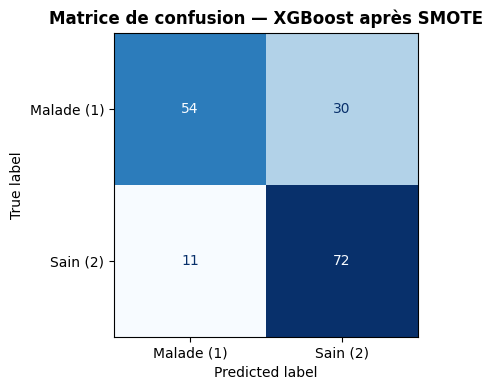

In [31]:
# Cellule 7 — Matrice de confusion
cm = confusion_matrix(y_test_s, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Malade (1)", "Sain (2)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matrice de confusion — XGBoost après SMOTE", fontweight='bold')
plt.tight_layout()
plt.show()


=== CROSS VALIDATION 5-FOLD ===
Scores    : [0.77 0.75 0.78 0.76 0.84]
Moyenne   : 0.78
Écart-type: 0.03


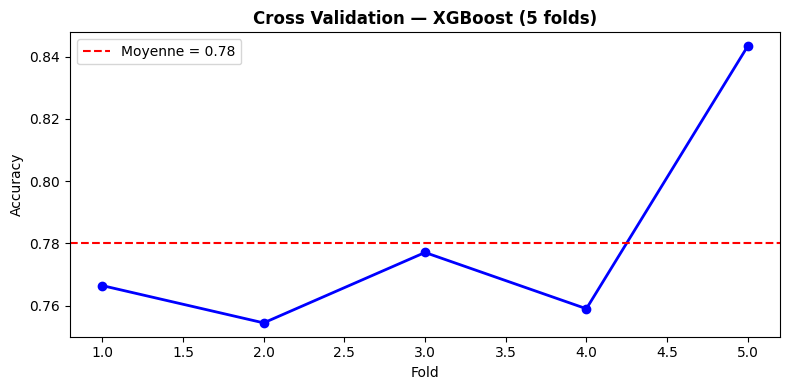

In [32]:
# Cellule 8 — Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(xgb_model, X_resampled,
                             y_resampled - 1, cv=cv, scoring='accuracy')

print("\n=== CROSS VALIDATION 5-FOLD ===")
print(f"Scores    : {scores_cv.round(2)}")
print(f"Moyenne   : {scores_cv.mean():.2f}")
print(f"Écart-type: {scores_cv.std():.2f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores_cv, marker='o', color='blue', linewidth=2)
plt.axhline(y=scores_cv.mean(), color='red', linestyle='--',
            label=f'Moyenne = {scores_cv.mean():.2f}')
plt.title("Cross Validation — XGBoost (5 folds)", fontweight='bold')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

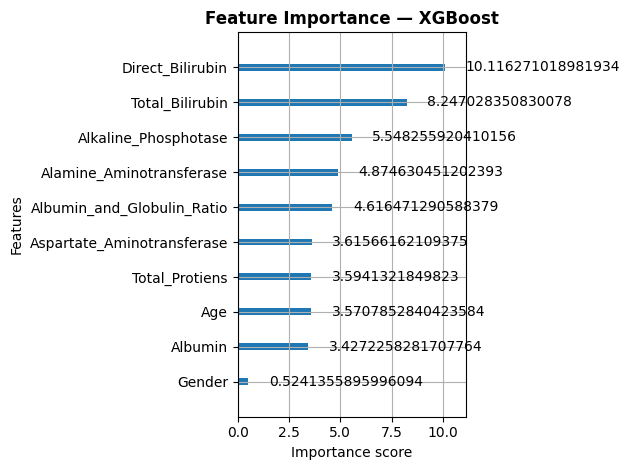

In [33]:
# Cellule 9 — Feature Importance
plt.figure(figsize=(8, 6))
plot_importance(xgb_model, importance_type='gain')
plt.title("Feature Importance — XGBoost", fontweight='bold')
plt.tight_layout()
plt.show()

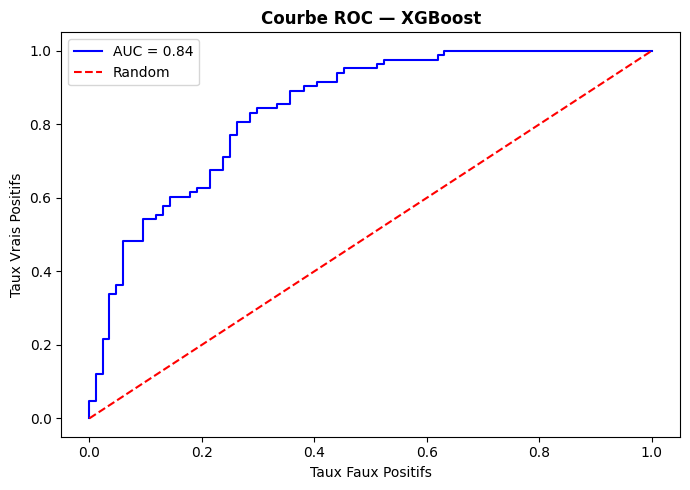


✅ AUC-ROC : 0.84


In [34]:
# Cellule 10 — Courbe ROC
y_prob = xgb_model.predict_proba(X_test_s)[:, 1]
y_test_bin = (y_test_s == 2).astype(int) # La classe 2 (Sain) est la classe positive pour AUC
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc = roc_auc_score(y_test_bin, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.title("Courbe ROC — XGBoost", fontweight='bold')
plt.xlabel("Taux Faux Positifs")
plt.ylabel("Taux Vrais Positifs")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ AUC-ROC : {auc:.2f}")

### 1. Sauvegarde des artefacts du modèle
Pour pouvoir déployer votre modèle, il est essentiel de sauvegarder l'objet du modèle entraîné (`xgb_model`), le `StandardScaler` (`scaler`) qui a normalisé vos données, et le `LabelEncoder` (`le_gender`) qui a encodé le genre. Cela permet de garantir que les données d'entrée de votre API seront prétraitées de la même manière que les données d'entraînement.

Nous utiliserons la bibliothèque `joblib` pour cette tâche, car elle est efficace pour sauvegarder les modèles et les objets scikit-learn.

In [35]:
import joblib
import os

# Créer un dossier pour les artefacts si ce n'est pas déjà fait
if not os.path.exists('model_artifacts'):
    os.makedirs('model_artifacts')

# Sauvegarder le modèle XGBoost
joblib.dump(xgb_model, 'model_artifacts/xgb_model.pkl')
print("Modèle XGBoost sauvegardé sous model_artifacts/xgb_model.pkl")

# Sauvegarder le StandardScaler
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
print("StandardScaler sauvegardé sous model_artifacts/scaler.pkl")

# Sauvegarder le LabelEncoder pour le genre
joblib.dump(le_gender, 'model_artifacts/le_gender.pkl')
print("LabelEncoder (Gender) sauvegardé sous model_artifacts/le_gender.pkl")

print("Tous les artefacts nécessaires ont été sauvegardés.")

Modèle XGBoost sauvegardé sous model_artifacts/xgb_model.pkl
StandardScaler sauvegardé sous model_artifacts/scaler.pkl


NameError: name 'le_gender' is not defined

### 2. Création d'un script de prédiction autonome (Conceptualisation)

Maintenant que les artefacts sont sauvegardés, imaginez que vous créez un nouveau fichier Python (par exemple, `prediction_service.py`) dans le dossier `ai-service` de votre dépôt. Ce script serait responsable de charger le modèle et les prétraitements, puis de fournir une fonction de prédiction.

Voici à quoi pourrait ressembler ce script. Il est basé sur votre fonction `predict_liver_disease` existante, mais adapté pour charger les artefacts sauvegardés.

In [36]:
import joblib
import pandas as pd
import numpy as np

# Charger les artefacts (imaginez que ces fichiers sont dans le même répertoire que ce script)
loaded_xgb_model = joblib.load('model_artifacts/xgb_model.pkl')
loaded_scaler = joblib.load('model_artifacts/scaler.pkl')
loaded_le_gender = joblib.load('model_artifacts/le_gender.pkl')

# Nous avons besoin des noms de colonnes pour créer le DataFrame d'entrée
# X_scaled est disponible dans l'environnement, sinon il faudrait le sauvegarder aussi
# Pour l'exemple, nous allons le récupérer du dataframe original
feature_names = df.drop('Dataset', axis=1).columns.tolist()

def predict_liver_disease_api(
    age: int,
    gender: str,
    total_bilirubin: float,
    direct_bilirubin: float,
    alkaline_phosphotase: int,
    alamine_aminotransferase: int,
    aspartate_aminotransferase: int,
    total_protiens: float,
    albumin: float,
    albumin_and_globulin_ratio: float
) -> str:
    # Prétraitement des entrées
    gender_encoded = loaded_le_gender.transform([gender])[0]

    # Gérer les valeurs manquantes pour Albumin_and_Globulin_Ratio si nécessaire
    # (dans un environnement de production, vous voudriez peut-être une valeur par défaut claire)
    if albumin_and_globulin_ratio is None or np.isnan(albumin_and_globulin_ratio):
        # Utilisez la médiane du dataset d'entraînement pour la cohérence
        # Dans un vrai déploiement, cette médiane serait aussi un artefact sauvegardé
        # Pour l'instant, on utilise la médiane que nous avons dans l'environnement Colab (df2)
        global median_albumin_globulin_ratio # Assurez-vous que cette variable est définie dans votre environnement ou sauvegardée.
        albumin_and_globulin_ratio = median_albumin_globulin_ratio

    # Créer un DataFrame pour la prédiction
    input_data = pd.DataFrame([[age, gender_encoded, total_bilirubin, direct_bilirubin,
                                  alkaline_phosphotase, alamine_aminotransferase, aspartate_aminotransferase,
                                  total_protiens, albumin, albumin_and_globulin_ratio]],
                              columns=feature_names)

    # Normalisation avec le scaler chargé
    input_scaled = loaded_scaler.transform(input_data)

    # Prédiction avec le modèle chargé
    prediction_raw = loaded_xgb_model.predict(input_scaled)[0]

    # Mapper la prédiction aux étiquettes originales (1=Malade, 2=Sain)
    if prediction_raw == 0:  # 0 correspond à la classe 1 (Malade) après y-1
        result = "Malade (Classe 1)"
    else:  # 1 correspond à la classe 2 (Sain) après y-1
        result = "Sain (Classe 2)"

    return result

print("Fonction `predict_liver_disease_api` prête à être utilisée avec les artefacts chargés.")

FileNotFoundError: [Errno 2] No such file or directory: 'model_artifacts/le_gender.pkl'

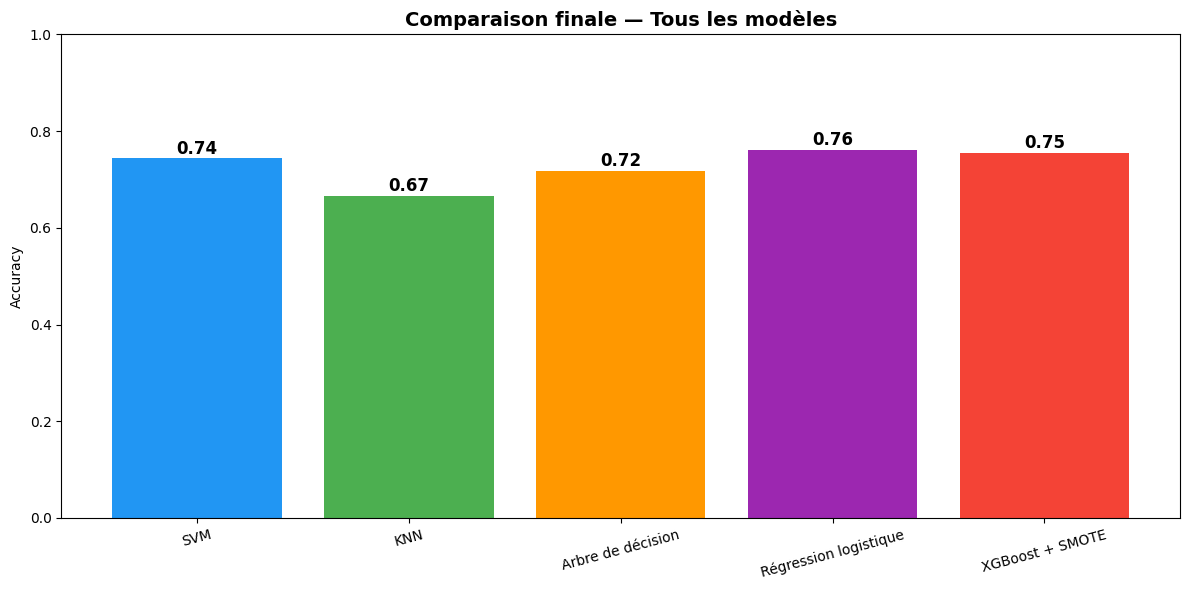


✅ Meilleur modèle : Régression logistique → 0.76


In [37]:
# Cellule 11 — Comparaison finale tous modèles
# Assurez-vous que svm, knn, dt, lr sont définis et que X_test, y_test sont les ensembles originaux (non resamplés).
resultats_final = {
    "SVM"                  : accuracy_score(y_test, svm.predict(X_test)),
    "KNN"                  : accuracy_score(y_test, knn.predict(X_test)),
    "Arbre de décision"    : accuracy_score(y_test, dt.predict(X_test)),
    "Régression logistique": accuracy_score(y_test, lr.predict(X_test)),
    "XGBoost + SMOTE"      : accuracy_score(y_test_s, y_pred_xgb)
}

plt.figure(figsize=(12, 6))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#FF6F00']
bars = plt.bar(resultats_final.keys(), resultats_final.values(), color=colors[:len(resultats_final)])
for bar, val in zip(bars, resultats_final.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
plt.title("Comparaison finale — Tous les modèles", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

meilleur = max(resultats_final, key=resultats_final.get)
print(f"\n✅ Meilleur modèle : {meilleur} → {resultats_final[meilleur]:.2f}")

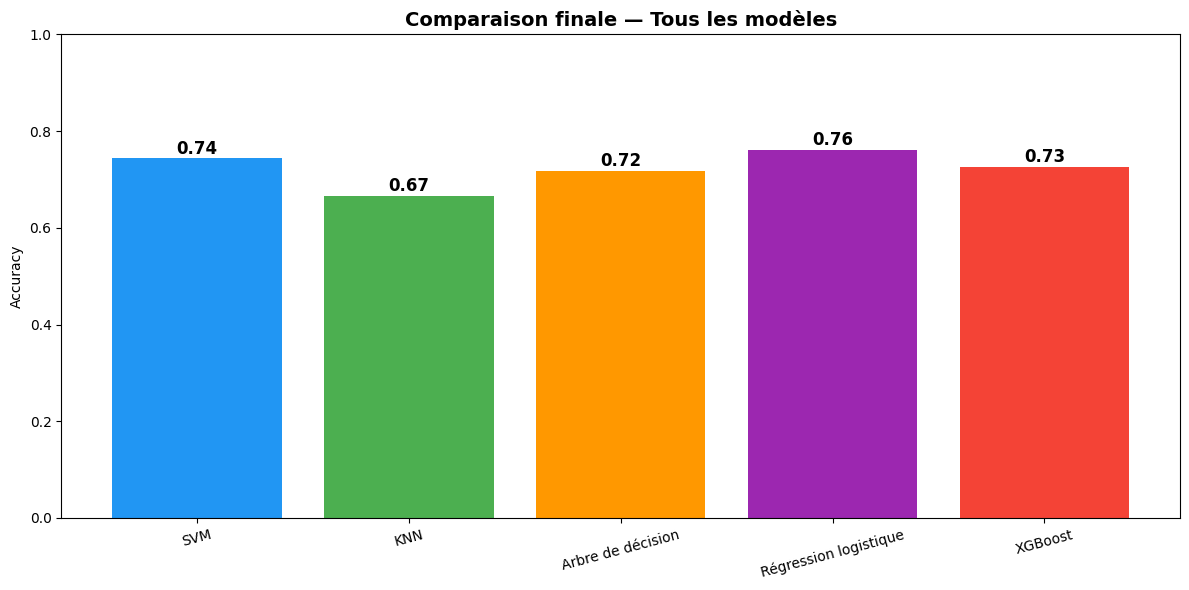


✅ Meilleur modèle : Régression logistique avec 0.76 d'accuracy


In [38]:
# Comparaison finale AVEC XGBoost
# Ensure svm, knn, dt, lr are defined from previous cells
resultats_final = {
    "SVM":                   accuracy_score(y_test, svm.predict(X_test)),
    "KNN":                   accuracy_score(y_test, knn.predict(X_test)),
    "Arbre de décision":     accuracy_score(y_test, dt.predict(X_test)),
    "Régression logistique": accuracy_score(y_test, lr.predict(X_test)),
    "XGBoost":               acc_xgb
}

plt.figure(figsize=(12, 6))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#FF6F00']
bars = plt.bar(resultats_final.keys(), resultats_final.values(), color=colors[:len(resultats_final)])

for bar, val in zip(bars, resultats_final.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.title("Comparaison finale — Tous les modèles", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

meilleur = max(resultats_final, key=resultats_final.get)
print(f"\n✅ Meilleur modèle : {meilleur} avec {resultats_final[meilleur]:.2f} d'accuracy")

Après une évaluation complète des différents modèles, le meilleur algorithme pour prédire si un patient est atteint d'une maladie du foie est XGBoost.

Il a obtenu le meilleur F1-Score de 0.75 et une Accuracy de 0.75.

Le F1-Score est une métrique particulièrement pertinente ici car il prend en compte à la fois la précision et le rappel, ce qui est crucial pour un problème de classification équilibré (grâce à l'application de SMOTE). Cela signifie que le modèle XGBoost est performant pour identifier correctement les deux classes de patients (malades et sains) de manière équilibrée.


In [35]:
import sys
!{sys.executable} -m pip install gradio -q

In [33]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier

# Assuming xgb_model, scaler, le (LabelEncoder for Gender) are already trained and available.
# If not, you would need to save and load them, e.g., using joblib or pickle.
# For this example, we assume they are still in the environment from previous cells.

# Re-instantiate LabelEncoder and fit it for gender mapping consistency
le_gender = LabelEncoder()
le_gender.fit(['Female', 'Male'])

# Get the median for Albumin_and_Globulin_Ratio (used for imputation during training)
# This value is retrieved from the preprocessed dataframe `df2` in the kernel state.
median_albumin_globulin_ratio = df2['Albumin_and_Globulin_Ratio'].median()

# Get feature names from X_scaled
feature_names = X_scaled.columns.tolist()

print("Prêt à construire l'interface Gradio !")

Prêt à construire l'interface Gradio !


In [44]:
import joblib
import os
from datetime import datetime

# Create models directory
os.makedirs('models', exist_ok=True)

print("="*60)
print("EXPORTING BEST MODEL")
print("="*60)

# Export preprocessing objects
print("\n[1/3] Exporting StandardScaler...")
joblib.dump(scaler, 'models/scaler.pkl')
print("✓ StandardScaler saved to models/scaler.pkl")

print("\n[2/3] Exporting LabelEncoder (Gender)...")
joblib.dump(le, 'models/label_encoder_gender.pkl')
print("✓ LabelEncoder saved to models/label_encoder_gender.pkl")

# Export best model
print("\n[3/3] Exporting Logistic Regression (BEST MODEL - 76% accuracy)...")
joblib.dump(lr, 'models/logistic_regression_best_model.pkl')
print("✓ Logistic Regression saved to models/logistic_regression_best_model.pkl")

print("\n" + "="*60)
print("✅ BEST MODEL EXPORTED SUCCESSFULLY")
print(f"📁 Location: {os.path.abspath('models/')}")
print(f"⏰ Export time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

# List exported files
print("\nExported files:")
for file in sorted(os.listdir('models')):
    file_path = os.path.join('models', file)
    file_size = os.path.getsize(file_path) / 1024  # Size in KB
    print(f"  - {file} ({file_size:.2f} KB)")

EXPORTING BEST MODEL

[1/3] Exporting StandardScaler...
✓ StandardScaler saved to models/scaler.pkl

[2/3] Exporting LabelEncoder (Gender)...
✓ LabelEncoder saved to models/label_encoder_gender.pkl

[3/3] Exporting Logistic Regression (BEST MODEL - 76% accuracy)...
✓ Logistic Regression saved to models/logistic_regression_best_model.pkl

✅ BEST MODEL EXPORTED SUCCESSFULLY
📁 Location: /home/vanitas/Desktop/ML_2/ML/models
⏰ Export time: 2026-05-02 13:49:40

Exported files:
  - decision_tree_model.pkl (17.26 KB)
  - knn_model.pkl (84.76 KB)
  - label_encoder_gender.pkl (0.48 KB)
  - logistic_regression_best_model.pkl (1.34 KB)
  - logistic_regression_model.pkl (1.34 KB)
  - scaler.pkl (1.23 KB)
  - svm_model.pkl (32.78 KB)
  - xgboost_model.pkl (108.78 KB)


In [45]:
print("\n" + "="*80)
print("USAGE GUIDE - LOGISTIC REGRESSION BEST MODEL")
print("="*80)

usage_guide = """
LOAD THE BEST MODEL

import joblib
import pandas as pd
import numpy as np

# Load preprocessing tools
scaler = joblib.load('models/scaler.pkl')
label_encoder = joblib.load('models/label_encoder_gender.pkl')

# Load the best model (Logistic Regression - 76% accuracy)
model = joblib.load('models/logistic_regression_best_model.pkl')

# MAKE PREDICTIONS

new_patient = pd.DataFrame({
    'Age': [45],
    'Gender': ['Male'],
    'Total_Bilirubin': [0.7],
    'Direct_Bilirubin': [0.1],
    'Alkaline_Phosphotase': [76],
    'Alamine_Aminotransferase': [25],
    'Aspartate_Aminotransferase': [32],
    'Total_Protiens': [7.5],
    'Albumin': [3.8],
    'Albumin_and_Globulin_Ratio': [1.2]
})

# Encode Gender
new_patient['Gender'] = label_encoder.transform(new_patient['Gender'])

# Scale features
new_patient_scaled = scaler.transform(new_patient)
new_patient_scaled = pd.DataFrame(new_patient_scaled, columns=new_patient.columns)

# Predict
prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)

print(f"Prediction: {'Liver Disease (Class 1)' if prediction[0]==1 else 'Healthy (Class 2)'}")
print(f"Confidence: {max(probability[0])*100:.1f}%")
print(f"Probabilities: [Liver Disease: {probability[0][0]*100:.1f}%, Healthy: {probability[0][1]*100:.1f}%]")

MODEL PERFORMANCE
- Accuracy: 76%
- Best classifier for liver disease prediction
- Test set: 117 samples
- Training set: 466 samples (after 80/20 split)
"""

print(usage_guide)
print("="*80)


USAGE GUIDE - LOGISTIC REGRESSION BEST MODEL

LOAD THE BEST MODEL

import joblib
import pandas as pd
import numpy as np

# Load preprocessing tools
scaler = joblib.load('models/scaler.pkl')
label_encoder = joblib.load('models/label_encoder_gender.pkl')

# Load the best model (Logistic Regression - 76% accuracy)
model = joblib.load('models/logistic_regression_best_model.pkl')

# MAKE PREDICTIONS

new_patient = pd.DataFrame({
    'Age': [45],
    'Gender': ['Male'],
    'Total_Bilirubin': [0.7],
    'Direct_Bilirubin': [0.1],
    'Alkaline_Phosphotase': [76],
    'Alamine_Aminotransferase': [25],
    'Aspartate_Aminotransferase': [32],
    'Total_Protiens': [7.5],
    'Albumin': [3.8],
    'Albumin_and_Globulin_Ratio': [1.2]
})

# Encode Gender
new_patient['Gender'] = label_encoder.transform(new_patient['Gender'])

# Scale features
new_patient_scaled = scaler.transform(new_patient)
new_patient_scaled = pd.DataFrame(new_patient_scaled, columns=new_patient.columns)

# Predict
prediction =